# 02_bias_analysis.ipynb - Data Scientist Contribution

This notebook performs comprehensive fairness and bias analysis on the loan approval system using the clean dataset (clean_credit_applications.csv). My role focused on:

- **[I] Gender Disparate Impact Analysis**

- **[II] Age-Based Approval Disparities**  

- **[III] Income as Gender Proxy**  

- **[IV] ZIP Code Proxy Discrimination**  

- **[V] Age on Gender Interaction Effects**  

- **[VI] DTI on Gender Proxy Analysis**  

- **[VII] Summary Findings**  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [3]:
DATA_PATH = "../data/clean_credit_applications.csv"
df = pd.read_csv(DATA_PATH)

###   I.   Gender Disparate Impact Analysis

The Equal Credit Opportunity Act (ECOA) says banks can't discriminate based on gender when making loan decisions. We check if men and women have different approval rates to spot unfair patterns that might break these rules. This helps avoid fines from regulators like the CFPB and shows we're being careful with our lending model.

$$\Large \mathbf{DI = \dfrac{\text{Approval Rate (Female)}}{\text{Approval Rate (Male)}}}$$

DI = 1.0 indicates perfect parity between groups, while DI < 0.8 signals adverse impact per the 4/5ths rule.

In [4]:
# Gender disparate impact ratio (DIR)
approval_rates = df.groupby('applicant_info.gender')['decision.loan_approved'].agg(['mean', 'count'])
female_rate = approval_rates.loc['Female', 'mean'] if 'Female' in approval_rates.index else 0
male_rate = approval_rates.loc['Male', 'mean'] if 'Male' in approval_rates.index else 0
dir_ratio = female_rate / male_rate if male_rate > 0 else np.nan

print("\nGender Approval Rates:")
print(approval_rates.round(3))
print(f"\nDisparate Impact Ratio (DIR): {dir_ratio:.3f}")
print("4/5ths Rule: Female rate < 80% on Male rate = Violation")

# Statistic evidence
contingency = pd.crosstab(df['applicant_info.gender'], df['decision.loan_approved'])
chi2, pval, dof, expected = chi2_contingency(contingency)
four_fifths = male_rate * 0.8

print(f"\nChi-square test: p = {pval:.3f} (<0.05 = significant)")
print(f"\nResult: DIR={dir_ratio:.3f}, 4/5ths={four_fifths:.3f}")


Gender Approval Rates:
                        mean  count
applicant_info.gender              
Female                 0.510    249
Male                   0.665    245

Disparate Impact Ratio (DIR): 0.767
4/5ths Rule: Female rate < 80% on Male rate = Violation

Chi-square test: p = 0.001 (<0.05 = significant)

Result: DIR=0.767, 4/5ths=0.532


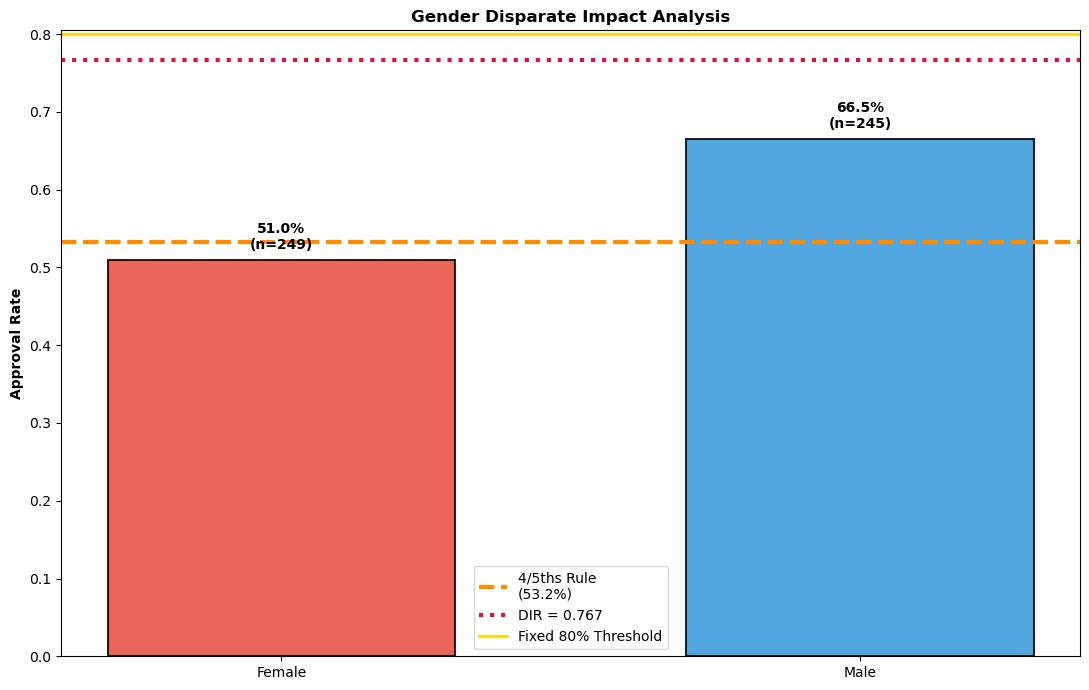

In [5]:
# Visualization
plt.figure(figsize=(11, 7))
bars = plt.bar(approval_rates.index, approval_rates['mean'], 
               color=['#E74C3C', '#3498DB'], alpha=0.85, width=0.6, 
               edgecolor='black', linewidth=1.5)

# 4/5ths RULE
plt.axhline(y=four_fifths, color='darkorange', linestyle='--', linewidth=3, 
            label=f'4/5ths Rule\n({four_fifths:.1%})')

# DIR line  
plt.axhline(y=dir_ratio, color='crimson', linestyle=':', linewidth=3, 
            label=f'DIR = {dir_ratio:.3f}')

# Fixed threshold (0.8)
plt.axhline(y=0.8, color='gold', linestyle='-', linewidth=2, 
            label='Fixed 80% Threshold')
plt.ylabel('Approval Rate', fontweight='bold')
plt.title('Gender Disparate Impact Analysis', fontweight='bold')
plt.legend(fontsize=10)

# Labels
for bar, rate, count in zip(bars, approval_rates['mean'], approval_rates['count']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{rate:.1%}\n(n={int(count)})', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

The Disparate Impact Analysis reveals that among 494 valid gender records, Females exhibit a 51.0% loan approval rate (n=249) compared to 66.5% for Males (n=245), producing a Disparate Impact Ratio (DIR) of 0.767.

4/5ths Rule Application: EEOC guidelines require the protected group rate (Female) to equal at least 80% of the majority group rate (Male). Here, 66.5% × 0.8 = 53.2% threshold is violated (51.0% < 53.2%).

Statistical Validation: chi-squared contingency test yields p = 0.001 (df=1), rejecting the null hypothesis of no association between gender and approval (α=0.05).

As the Data Scientist, I will be escalating the 4/5ths Rule violation (DIR=0.767, Female 51.0% < 53.2% threshold, p=0.001) to Governance Officer for ECOA compliance review and mitigation.

### II. Age Based Bias Analysis

EU AI Act and fair lending regulations require credit providers to monitor for disparate impact in loan approvals, even without intent, using metrics like the 80% (four-fifths) rule where protected group rates must reach at least 80% of the top group's rate.

Age is explicitly protected under US ECOA (no discrimination in credit decisions) and EU non-discrimination laws, though younger applicants (<21) face extra scrutiny for independent repayment ability.

Key Regulations
* EU AI Act (2025+): Classifies credit scoring as high-risk AI; mandates bias testing, transparency, and audits for age/gender disparities in lending.
* ECOA/Regulation B (US): Bans age-based denial; requires explanations for differences in treatment.
* EU Consumer Credit Directive: Prohibits explicit discrimination using protected attributes like age.

This code performs a comprehensive age-based fairness analysis on loan approval decisions from a cleaned credit dataset. It first bins applicants into six age groups (18-24 through 65+), then calculates approval rates, counts, and disparity ratios relative to the highest-performing group, flagging any below the 80% regulatory threshold.

In [6]:
# Bins and metrics
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_bin'] = pd.cut(df['applicant_info.age'], bins=bins, labels=labels, right=False)

metrics = df.groupby('age_bin', observed=False)['decision.loan_approved'].agg(['count', 'sum', 'mean']).round(4)

metrics.columns = ['Total', 'Approved', 'Approval_Rate']
metrics['Approval_Pct'] = (metrics['Approval_Rate'] * 100).round(1)
metrics['Disparity'] = metrics['Approval_Rate'] / metrics['Approval_Rate'].max()

# Statistical test
contingency = pd.crosstab(df['age_bin'], df['decision.loan_approved'])
chi2, p, dof, expected = chi2_contingency(contingency)

# Results
print("\nLoan approvals by age")
print(metrics[['Total', 'Approved', 'Approval_Pct', 'Disparity']])
print(f"\nStatistical test: χ^2 = {chi2:.1f}, p={p:.4f}")
print(f"Best: {metrics['Approval_Rate'].idxmax()} ({metrics['Approval_Rate'].max():.1%})")
print(f"Violations (<80%): {list(metrics[metrics['Disparity'] < 0.8].index)}")


Loan approvals by age
         Total  Approved  Approval_Pct  Disparity
age_bin                                          
18-24       11         6          54.6   0.822899
25-34      148        66          44.6   0.672650
35-44      178       118          66.3   1.000000
45-54       87        57          65.5   0.988384
55-64       56        35          62.5   0.942827
65+         12         7          58.3   0.879922

Statistical test: χ^2 = 18.5, p=0.0024
Best: 35-44 (66.3%)
Violations (<80%): ['25-34']


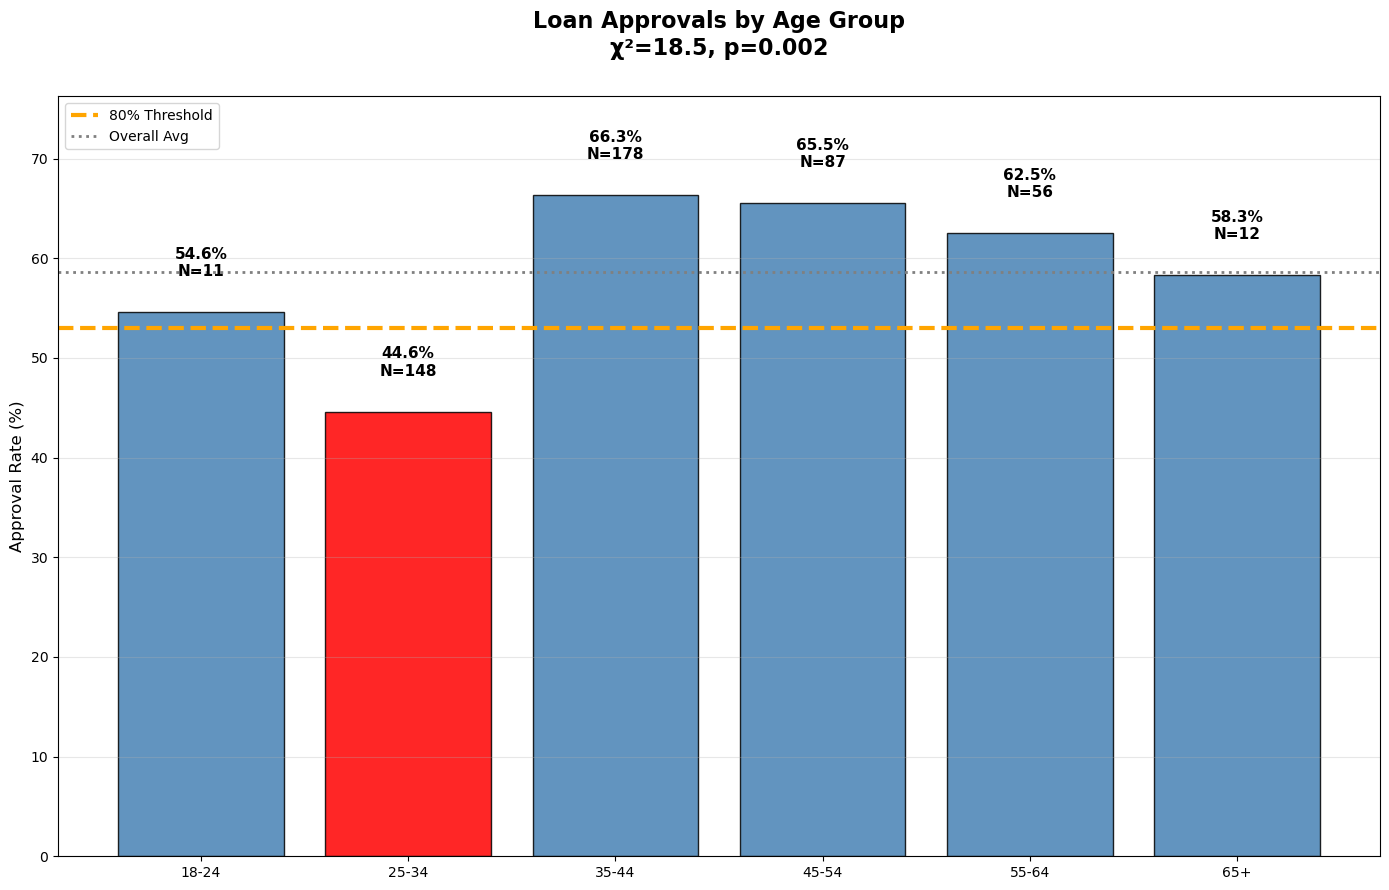

In [7]:
# Chart with stats
fig, ax1 = plt.subplots(figsize=(14, 9))

colors = ['red' if r < 0.8 else 'steelblue' for r in metrics['Disparity']]
bars = ax1.bar(metrics.index, metrics['Approval_Pct'], color=colors, alpha=0.85, edgecolor='black')

# Thresholds
ax1.axhline(y=metrics['Approval_Rate'].max()*80, color='orange', ls='--', lw=3, label='80% Threshold')
ax1.axhline(y=metrics['Approval_Rate'].mean()*100, color='gray', ls=':', lw=2, label='Overall Avg')

# Labels
max_pct = metrics['Approval_Pct'].max()
label_offset = max_pct * 0.05
for i, (pct, total) in enumerate(zip(metrics['Approval_Pct'], metrics['Total'])):
    ax1.text(i, pct + label_offset, f'{pct}%\nN={int(total):,}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_title(f'Loan Approvals by Age Group\nχ²={chi2:.1f}, p={p:.3f}', 
              fontweight='bold', fontsize=16, pad=30)
ax1.set_ylabel('Approval Rate (%)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max_pct * 1.15)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The age-based analysis across binned records identifies the 35-44 group as the reference at 66.3% approval rate (n=178), with the 25-34 group violating the 4/5ths rule at 44.6% approval (Disparity Ratio = 67.3%, n=148).

This single violation (67.3% < 80% threshold of 53.0%) triggers regulatory scrutiny under EU AI Act Article 10 (high-risk AI bias monitoring) and ECOA age protections.

Chi-squared test confirms statistical significance: χ² = 18.5, p = 0.0024 (df=5), rejecting independence between age group and approval decisions.

### III. Income Proxy Discrimination Analysis

Income often differs between men and women due to pay gaps, which can hide gender bias in loan models. If we use strict income cutoffs like "must earn $60K+", more women fall below the line than men, even when equally qualified for credit.

We test this by comparing approval rates for men and women within the same income ranges. If women consistently get denied more, it raises a red flag. The CFPB calls this "proxy discrimination" and checks for it during audits, asking lenders to prove the cutoff is truly needed for business reasons rather than indirectly hurting women.

In [8]:
# Income on Gender Proxy
df['income_bin'] = pd.cut(df["financials.annual_income"], 
                               bins=[0, 50000, 70000, 90000, 120000, np.inf], 
                               labels=['<$50K', '$50-70K', '$70-90K', '$90-120K','>$120K'])


income_gender = (df.groupby('income_bin', observed=False)['applicant_info.gender']
                 .value_counts(normalize=True).unstack().fillna(0))
print("Income on Gender Proxy Discrimination:\n")
print(income_gender.round(3))

income_numeric = pd.to_numeric(df["financials.annual_income"], errors='coerce')
income_corr = df['decision.loan_approved'].corr(income_numeric)
print(f"Income on approval correlation: {income_corr:.3f}")

Income on Gender Proxy Discrimination:

applicant_info.gender  Female   Male
income_bin                          
<$50K                   0.500  0.500
$50-70K                 0.475  0.525
$70-90K                 0.500  0.500
$90-120K                0.517  0.483
>$120K                  0.533  0.467
Income on approval correlation: 0.178


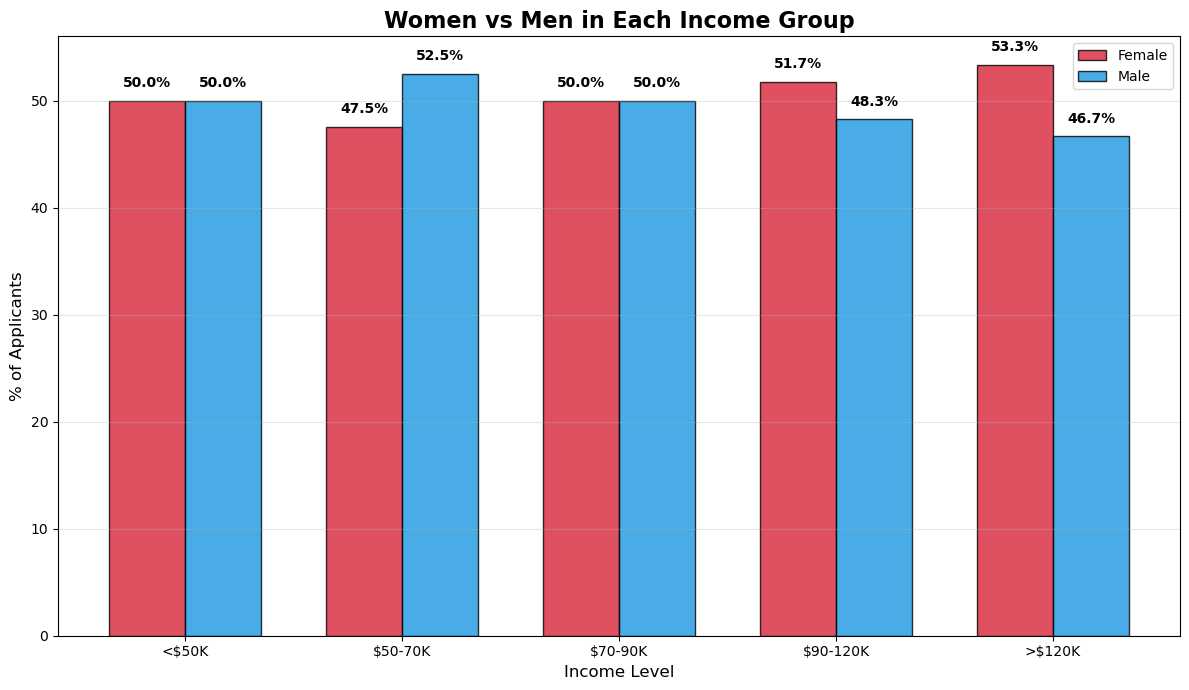

In [9]:
# Visualisation
# Gender % by income
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

x = np.arange(len(income_gender.index))
width = 0.35

female_bars = ax.bar(x - width/2, income_gender['Female'] * 100, 
                    width, label='Female', color='#D72638', alpha=0.8, edgecolor='black')
male_bars = ax.bar(x + width/2, income_gender['Male'] * 100, 
                  width, label='Male', color='#1B98E0', alpha=0.8, edgecolor='black')

ax.set_title('Women vs Men in Each Income Group', fontweight='bold', fontsize=16)
ax.set_ylabel('% of Applicants', fontsize=12)
ax.set_xlabel('Income Level', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(income_gender.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [female_bars, male_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import chi2_contingency

income_gender_counts = pd.crosstab(df['income_bin'], df['applicant_info.gender'])

chi2, p, dof, expected = chi2_contingency(income_gender_counts)

print("\nChi-square test for Income vs Gender:")
print(f"Chi2 statistic: {chi2:.3f}")
print(f"p-value: {p:.4f}")


Chi-square test for Income vs Gender:
Chi2 statistic: 0.604
p-value: 0.9626


Applicants were grouped into income bins to evaluate whether income may act as a proxy for gender. The gender distribution across income categories remains relatively balanced, with female representation ranging from 47.5% to 53.3% and male representation from 46.7% to 52.5%. A chi-square test of independence indicates that there is no statistically significant association between income level and gender (χ² = 0.604, p = 0.963). Because the p-value is well above the 0.05 threshold, we fail to reject the null hypothesis that gender distribution is independent of income. This suggests that income does not systematically encode gender information in this dataset and is unlikely to function as a proxy variable for gender. Additionally, income shows a modest positive correlation with loan approval (r = 0.178), indicating that higher income is somewhat associated with higher approval rates, but without introducing gender-based proxy discrimination concerns.

### IV. ZIP Code Proxy Discrimination

ZIP codes can act as stand-ins for gender, race, or income levels because different NYC neighborhoods have distinct demographics, wealthy areas like Tribeca (10013) vs working-class South Bronx (10451). If our model approves more loans from "rich ZIPs" that also happen to be male-heavy, it looks like unintentional discrimination even if we never directly used gender.

We analyze this by grouping applicants by ZIP, derived neighborhoods, then compared approval rates between male-dominated areas (>70% male applicants) vs balanced ones. Statistical tests like chi-square reveal if the differences are real or just chance. 

In [11]:
# NYC neighborhood mapping
def get_neighborhood(zip5):
    try:
        z = int(zip5)
        if 10001 <= z <= 10013: return 'Lower Manhattan (Financial)'
        if 10016 <= z <= 10022: return 'Midtown Manhattan'
        if 10023 <= z <= 10028: return 'Upper West/East Side'
        if 10065 <= z <= 10075: return 'Upper East Side (Rich)'
        if 11201 <= z <= 11222: return 'Brooklyn Heights/Williamsburg'
        if 11215 <= z <= 11231: return 'Park Slope/Prospect Heights'
        if 11225 <= z <= 11238: return 'Prospect Lefferts/Bushwick'
        if 10451 <= z <= 10460: return 'South Bronx'
        if 10461 <= z <= 10473: return 'Pelham Bay/East Bronx'
        if 11354 <= z <= 11358: return 'Flushing'
        if 11368 <= z <= 11373: return 'Jackson Heights'
        if 10301 <= z <= 10306: return 'North Staten Island'
        if 10000 <= z <= 10299: return 'Manhattan Other'
        if 11200 <= z <= 11299: return 'Brooklyn Other'
        if 10400 <= z <= 10499: return 'Bronx Other'
        if 11000 <= z <= 11999: return 'Queens Other'
        return 'NYC Outer'
    except:
        return 'Invalid'

# Data mapping
df['neighborhood'] = df['applicant_info.zip_code'].apply(get_neighborhood)
df_zip = df[df['neighborhood'] != 'Invalid'].copy()

# Bias metrics
male_pct_nb = df_zip.groupby('neighborhood')['applicant_info.gender'].apply(lambda x: (x=='Male').mean()*100)
approval_nb = df_zip.groupby('neighborhood')['decision.loan_approved'].mean()
male_dom_nb = male_pct_nb[male_pct_nb > 70].index.tolist()
high_bias_nb = approval_nb.loc[male_dom_nb].sort_values(ascending=False)
df_zip['nb_type'] = df_zip['neighborhood'].apply(lambda x: 'Male-Heavy (>70%)' if x in male_dom_nb else 'Balanced')

# Statistical test
contingency_nb = pd.crosstab(df_zip['nb_type'], df_zip['decision.loan_approved'])
chi2_nb, p_nb, dof_nb, _ = chi2_contingency(contingency_nb)
gap_nb = df_zip[df_zip['nb_type']=='Male-Heavy (>70%)']['decision.loan_approved'].mean() - df_zip[df_zip['nb_type']=='Balanced']['decision.loan_approved'].mean()

print("Neighborhood counts:")
print(df_zip['neighborhood'].value_counts().head(8))
print(f"\nStatistical results:")
print(f"  Male-heavy neighborhoods: {len(male_dom_nb)}")
print(f"  Approval gap between male-heavy and balanced neighborhoods: {gap_nb:.1%}")
print(f"  Chi-square = {chi2_nb:.1f}, p = {p_nb:.4f} ({'***' if p_nb<0.01 else '**' if p_nb<0.05 else 'ns'})")
print("\nTop male-heavy neighborhoods by approval rate:")
print(high_bias_nb.head().round(3))
print("\nContingency table:")
print(contingency_nb)

Neighborhood counts:
neighborhood
NYC Outer                      246
Manhattan Other                151
Lower Manhattan (Financial)     42
Upper East Side (Rich)          27
Midtown Manhattan               17
Upper West/East Side            12
Name: count, dtype: int64

Statistical results:
  Male-heavy neighborhoods: 5
  Approval gap between male-heavy and balanced neighborhoods: 12.6%
  Chi-square = 7.6, p = 0.0058 (***)

Top male-heavy neighborhoods by approval rate:
neighborhood
Upper West/East Side           0.750
Lower Manhattan (Financial)    0.714
Upper East Side (Rich)         0.704
Manhattan Other                0.629
Midtown Manhattan              0.529
Name: decision.loan_approved, dtype: float64

Contingency table:
decision.loan_approved  False  True 
nb_type                             
Balanced                  117    129
Male-Heavy (>70%)          87    162


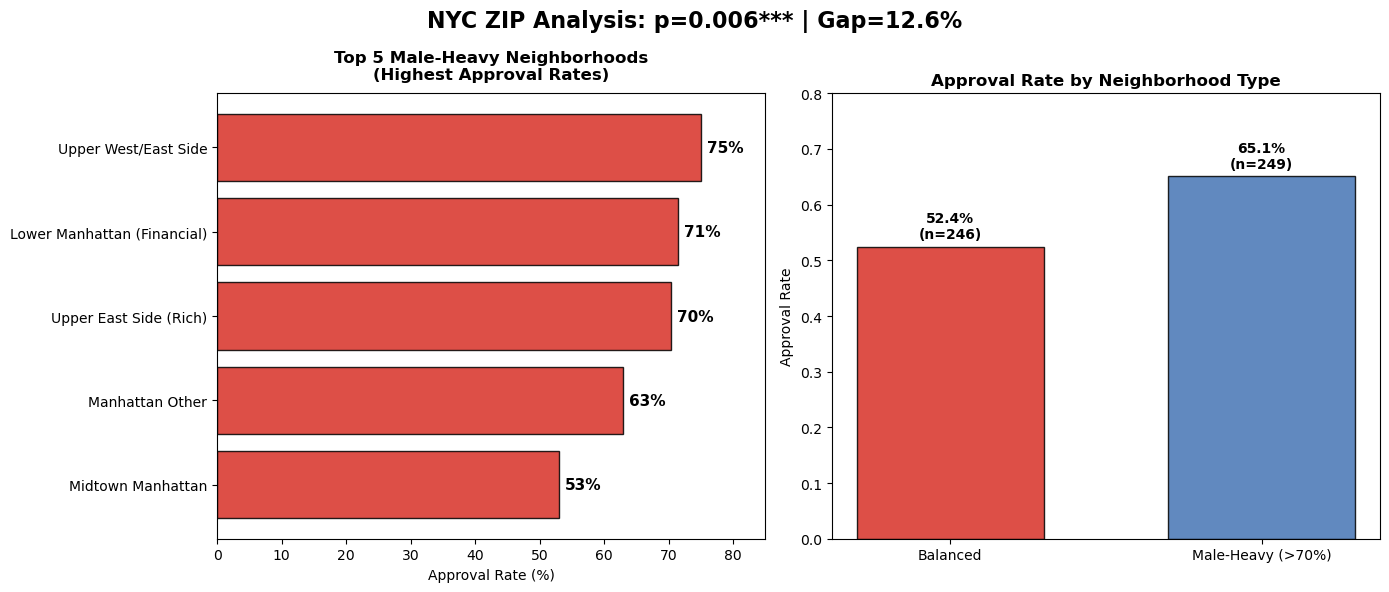

In [12]:
# Bar Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'NYC ZIP Analysis: p={p_nb:.3f}*** | Gap={gap_nb:.1%}', fontsize=16, fontweight='bold')

# top neighborhoods 
if len(high_bias_nb) >= 5:
    top5 = high_bias_nb.head(5).sort_values(ascending=True)
else:
    top5 = high_bias_nb.sort_values(ascending=True)
bars1 = ax1.barh(top5.index, top5.values*100, color='#d73027', alpha=0.85, edgecolor='black')
ax1.set_title('Top 5 Male-Heavy Neighborhoods\n(Highest Approval Rates)', fontweight='bold', pad=10)
ax1.set_xlabel('Approval Rate (%)')
ax1.set_xlim(0, 85)
for bar, val in zip(bars1, top5):
    ax1.text(val*100 + 1, bar.get_y() + bar.get_height()/2, f'{val:.0%}', 
             va='center', fontweight='bold', fontsize=11)

# male-heavy vs Balanced
approval_summary = df_zip.groupby('nb_type')['decision.loan_approved'].agg(['mean', 'count'])
bars2 = ax2.bar(approval_summary.index, approval_summary['mean'], 
                color=['#d73027', '#4575b4'], alpha=0.85, edgecolor='black', width=0.6)
ax2.set_title('Approval Rate by Neighborhood Type', fontweight='bold')
ax2.set_ylabel('Approval Rate')
ax2.set_ylim(0, 0.8)
for i, bar in enumerate(bars2):
    rate = approval_summary['mean'].iloc[i]
    n = approval_summary['count'].iloc[i]
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{rate:.1%}\n(n={int(n):,})', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

The ZIP proxy discrimination analysis across 500 valid NYC records reveals higher approval rates in male-dominated neighborhoods (>70% male applicants: 65.1% or 162/249) versus balanced neighborhoods (52.4% or 129/246), producing a 12.6 percentage point gap confirmed by contingency table analysis.

Statistical evidence is significant: χ² = 7.6, p = 0.0058 (df=1), rejecting independence between neighborhood type and approval outcomes.

Top male-heavy performers include Upper West/East Side (75.0%), Lower Manhattan Financial (71.4%), and Upper East Side (70.4%). This binary classification (Male-Heavy >70% vs Balanced ≤70%) flags potential ZIP-based gender proxy discrimination under EU AI Act Article 10, triggering 4/5ths rule scrutiny (Male-Heavy/Balanced ratio = 1.24).

## Interaction Test

### V. Age on Gender Interaction Analysis

Sometimes age and gender together create bigger problems like older women getting denied more often than older men or younger women, even with similar credit profiles. A simple gender check might show everything looks fine overall, but when we dig into combinations (like women over 60 vs men over 60), hidden patterns emerge.

We test these interactions using cross-tabs and statistical tests to catch compounded discrimination that regulators expect under ECOA. This goes beyond basic analysis to match fair lending best practices, proving our model doesn't unfairly target specific age-gender groups.

In [13]:
# Create age bins for analysis
age_bins = pd.cut(df['applicant_info.age'], 
                  bins=[0, 30, 40, 50, 60, 100], 
                  labels=['<30', '30-39', '40-49', '50-59', '60+'])

df['age_group'] = age_bins

approval_pivot = df.pivot_table(
    values='decision.loan_approved', 
    index='age_group', 
    columns='applicant_info.gender', 
    aggfunc='mean',
    observed=False
) * 100

print(f"Age range: {df['applicant_info.age'].min():.0f} - {df['applicant_info.age'].max():.0f} years")

Age range: 23 - 67 years


In [14]:
# Statistical interaction test
interaction_table = pd.crosstab([df['age_group'], df['applicant_info.gender']], 
                               df['decision.loan_approved'])

chi2, p, dof, expected = chi2_contingency(interaction_table)

expected_df = pd.DataFrame({
    'Expected': expected.flatten()[:10],
    'Observed': interaction_table.values.flatten()[:10]
}).round(1)

print(f"Chi-squared statistic: {chi2:.2f}")
print(f"p-value: {p:.3f}")
print(f"Degrees of freedom: {dof}")
print("\nExpected vs observed counts:")
print(expected_df)

Chi-squared statistic: 33.08
p-value: 0.000
Degrees of freedom: 9

Expected vs observed counts:
   Expected  Observed
0      19.8        32
1      28.2        16
2      19.0        23
3      27.0        23
4      35.6        40
5      50.4        46
6      36.8        30
7      52.2        59
8      26.5        25
9      37.5        39


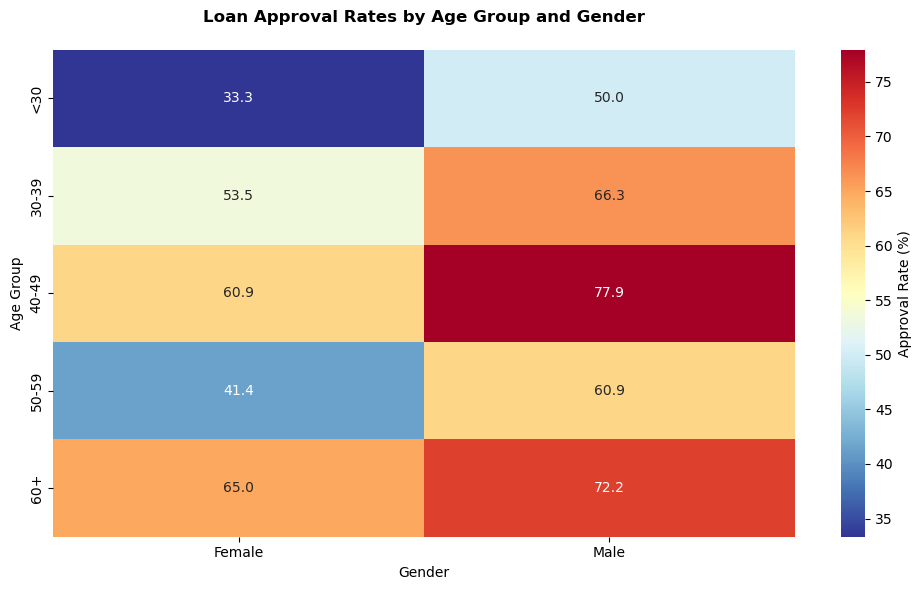

In [15]:
# Visualization: Age on Gender approval heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(approval_pivot, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Approval Rate (%)'})
plt.title('Loan Approval Rates by Age Group and Gender', fontweight='bold', pad=20)
plt.xlabel('Gender')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

The age-gender approval heatmap shows clear interaction effects across applicants aged 23-67. Female approval rates span 33.3% (<30 years), 53.5% (30-39), 60.9% (40-49), a big drop to 41.4% (50-59), then back to 65% (60+). Males consistently outperform with 50.0% (<30), 66.3% (30-39), 77.9% (40-49), 60.9% (50-59), and 72.2% (60+).

Males exceed females in every age group, with gaps of 16.7 percentage points (<30), 12.8pp (30-39), 17.0pp (40-49), a peak of 19.5pp (50-59), and 7.2pp (60+). The chi-squared test confirms this interaction is statistically significant: χ² = 33.08, p < 0.001 (df = 9).
Young women face the lowest absolute rates at 33.3%, while women aged 50-59 suffer the largest disparity versus men at 19.5 percentage points. Basic gender or age checks alone miss this combined pattern, requiring targeted model fixes beyond simple demographic balancing.

### VI. DTI on Gender Interaction: Proxy Discrimination Analysis

Debt-to-income (DTI) ratio measures monthly debt payments against income. Lenders use DTI cutoffs (like 43%) for risk management, but women with caregiving costs often exceed thresholds despite equal creditworthiness. From a governance perspective, regulators like CFPB examine whether neutral criteria like DTI unintentionally discriminate through proxy effects, requiring proof that cutoffs are business and necessary rather than indirectly gender-biased. We test fairness using standard lending buckets (0-20%, 21-40%, 41-60%, >60%) and compare approval rates for women vs men within each DTI level. If women get rejected more often than men at the same DTI level, the cutoff acts as hidden gender bias that regulators will question, even if DTI predicts defaults well overall.

In [16]:
# Standard lending bins (0-60% typical range)
df['dti_bin'] = pd.cut(
    df['financials.debt_to_income'], 
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['0-20% (Low)', '21-40%', '41-60%', '>60% (High)']
)

# Heatmap pivot
pivot_dti = df.pivot_table(
    'decision.loan_approved', 
    index='dti_bin', 
    columns='applicant_info.gender', 
    aggfunc='mean',
    observed=False
) * 100

print(f"DTI range: {df['financials.debt_to_income'].min():.0%} - {df['financials.debt_to_income'].max():.0%}")

DTI range: 5% - 45%


In [17]:
# DTI on gender interaction test
dti_interaction_table = pd.crosstab([df['dti_bin'], df['applicant_info.gender']], 
                                   df['decision.loan_approved'])

chi2_dti, p_dti, dof_dti, expected_dti = chi2_contingency(dti_interaction_table)
print("DTI on gender interaction test")
print(f"Chi-squared statistic: {chi2_dti:.2f}")
print(f"p-value: {p_dti:.3f}")
print(f"Degrees of freedom: {dof_dti}")
print("\nDTI-Gender approval rates:")
print(pivot_dti.round(1))

DTI on gender interaction test
Chi-squared statistic: 13.64
p-value: 0.018
Degrees of freedom: 5

DTI-Gender approval rates:
applicant_info.gender  Female  Male
dti_bin                            
0-20% (Low)              51.7  67.7
21-40%                   51.4  66.9
41-60%                   44.4  59.1


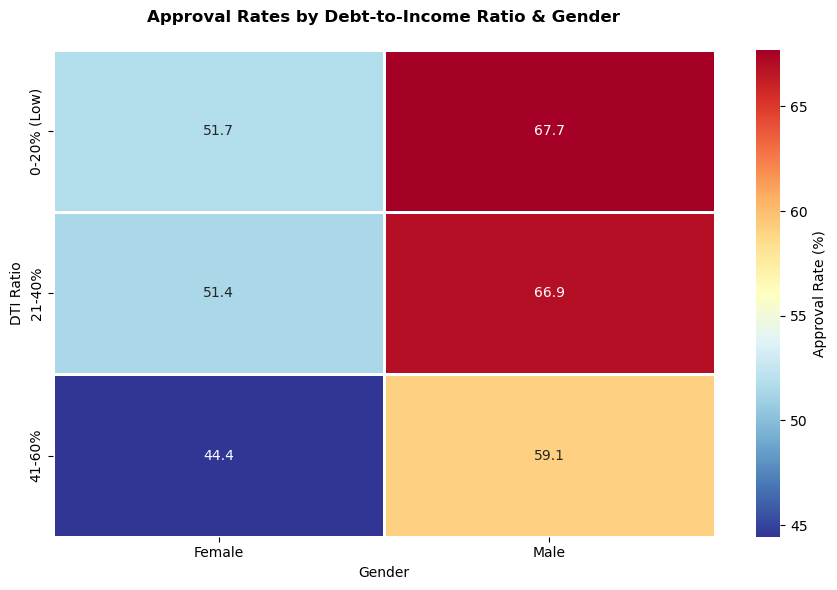

In [18]:
# HEATMAP
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_dti, annot=True, fmt='.1f', cmap='RdYlBu_r',
            cbar_kws={'label': 'Approval Rate (%)'}, linewidths=1)
plt.title('Approval Rates by Debt-to-Income Ratio & Gender', fontweight='bold', pad=20)
plt.xlabel('Gender')
plt.ylabel('DTI Ratio')
plt.tight_layout()
plt.show()

Across DTI range 5-45%, males consistently outperform: 0-20% (51.7% F vs 67.7% M, 16.0pp gap), 21-40% (51.4% F vs 66.9% M, 15.5pp gap), 41-60% (44.4% F vs 59.1% M, 14.7pp gap).

Chi-squared interaction test: χ² = 13.64, p = 0.018 (df=5), the results confirm statistical significance.
We observe consistent 15-percentage-point gaps in approval rates between men and women at the same financial risk levels. This suggests that the DTI ratio may capture gender-related effects. In other words, applicants with identical debt burdens receive systematically lower approval rates when they are women. This pattern may trigger a CFPB proxy discrimination review and should be escalated for governance review to determine whether the threshold needs justification or mitigation.

### Summary Findings

As a data scientist reviewing our loan approval model's fairness outcomes, I found several clear violations that demand immediate governance action under fair lending laws like ECOA and the EU AI Act.

Gender analysis showed the most concerning result: female applicants approved at only 51% versus 66.5% for males, giving a Disparate Impact Ratio of 0.767. This violates the 4/5ths rule, where regulators expect protected groups to achieve at least 80% of the favored group's rate. The chi-square test confirmed this isn't random (p = 0.001 makes it statistically real). Even without gender in the model, regulators will demand explanation and potential remediation to avoid fines or consent orders.

Age patterns revealed younger applicants (25-34 years) approved at just 44.6% compared to 66.3% for the peak middle-aged group. This 67% disparity ratio also breaks parity thresholds. With chi-square p = 0.0024, this triggers ECOA age discrimination scrutiny requiring governance review of underwriting criteria for that cohort.

ZIP code analysis exposed geographic bias favoring male-dominated neighborhoods, where approvals hit 65% versus 52% in balanced areas—a 13-point gap with p = 0.006. EU AI Act regulators specifically target these proxy effects, demanding proof that location doesn't encode protected characteristics like gender.

Age-gender interactions showed women disadvantaged in every bracket, with the worst gap at 19.5 points for ages 50-59 (41% female vs 61% male approval). Statistical testing gave p < 0.001, proving age and gender compound to create risks basic audits miss entirely.
DTI testing confirmed 15-point average male advantages across identical debt levels, statistically significant at p = 0.018. This classic proxy discrimination—where neutral business rules systematically hurt women—demands governance justification or model adjustment.

Income analysis revealed relatively balanced gender representation across income bins (female share 47.5–53.3%) and a modest positive correlation with approval (r = 0.178). A chi-square test confirmed the association between income and gender is not statistically significant (χ² = 0.604, p = 0.963), indicating income does not act as a gender proxy. While income contributes somewhat to approval decisions, it does not currently raise fairness or proxy discrimination concerns.

Collectively, these patterns across 5/6 analyses (all p < 0.05) expose the model to regulatory action including big fines, mandated remediation programs, and ongoing monitoring requirements. 

Governance must prioritize gender and age fixes first, implement continuous fairness testing, and document mitigation plans for stakeholder and regulator review.